In [1]:
import sys
import os

# Add the parent directory to sys.path so we can import znet without installing it
sys.path.append(os.path.abspath('..'))

import torch
from znet import SourceNode, MixingNode, StackNode, ConstantNode, CollapseNode, build_input_tensor, bind_graph_to_bus, value_and_derivatives, _
import matplotlib.pyplot as plt

print("znet imported successfully")

znet imported successfully


In [2]:
muA= SourceNode("mu_A")
muA_ref = ConstantNode(0)
muB = SourceNode("mu_B")

In [3]:
phase_a = _[muA@muA_ref | muB]
phase_b = _[muA | (muB @ ConstantNode(1)) ]
system = CollapseNode(phase_a + phase_b, scale=1e-6)

c:\Users\wellandm\Code\Znet\znet\nodes\geometry.py:43: RuntimeWarning: MixingNode initialized with enthalpy=None; Consider collapsing sub_nodes first.
  warnings.warn(


In [4]:
input_tensor, state_order = build_input_tensor(
    {
        "mu_A": torch.linspace(-10.0, 10.0, steps=10),
        "mu_B": torch.linspace(10.0, -10.0, steps=10),
        #"T": torch.tensor(293.15),
    },
    mode ="grid",
)

In [5]:
bind_graph_to_bus(phase_a, state_order)

{'mu_A': 0, 'mu_B': 1}

In [6]:
print("Input tensor shape:", input_tensor.shape)
print("muA slice shape:", muA(input_tensor).shape)
print("muA_ref shape:", muA_ref(input_tensor).shape)

phase_a_output = phase_a(input_tensor)
phase_b_output = phase_b(input_tensor)
system_output = system(input_tensor)
#print("Phase A output:", phase_a_output)
print("Phase A output shape:", phase_a_output.shape) 
print("Phase B output shape:", phase_b_output.shape)
print("System output shape:", system_output.shape)

Input tensor shape: torch.Size([10, 10, 2])
muA slice shape: torch.Size([10, 10, 1])
muA_ref shape: torch.Size([])
Phase A output shape: torch.Size([10, 10, 1])
Phase B output shape: torch.Size([10, 10, 1])
System output shape: torch.Size([10, 10, 1])


In [7]:
phase_a_output_2, phase_a_grad = value_and_derivatives(phase_a, input_tensor, n=1)

In [8]:
f = (input_tensor*phase_a_grad).sum(dim=-1).unsqueeze(-1)-phase_a_output_2

In [9]:
import plotly.graph_objects as go
import numpy as np

# Extract gradients and f values
grad_muA = phase_a_grad[..., 0].detach().numpy()  # shape (10, 10)
grad_muB = phase_a_grad[..., 1].detach().numpy()  # shape (10, 10)
f_vals   = f.squeeze(-1).detach().numpy()          # shape (10, 10)

fig = go.Figure(data=[
    go.Surface(
        x=grad_muA,
        y=grad_muB,
        z=f_vals,
        surfacecolor=f_vals,
        colorscale='Viridis',
        colorbar=dict(title='f value'),
        opacity=0.85,
    )
])

fig.update_layout(
    title='f vs gradients of Ω_A (parametric surface)',
    scene=dict(
        xaxis_title='∂Ω_A/∂μ_A  (N_A)',
        yaxis_title='∂Ω_A/∂μ_B  (N_B)',
        zaxis_title='f = μ·∇Ω − Ω',
    ),
    width=800,
    height=650,
)

fig.show()

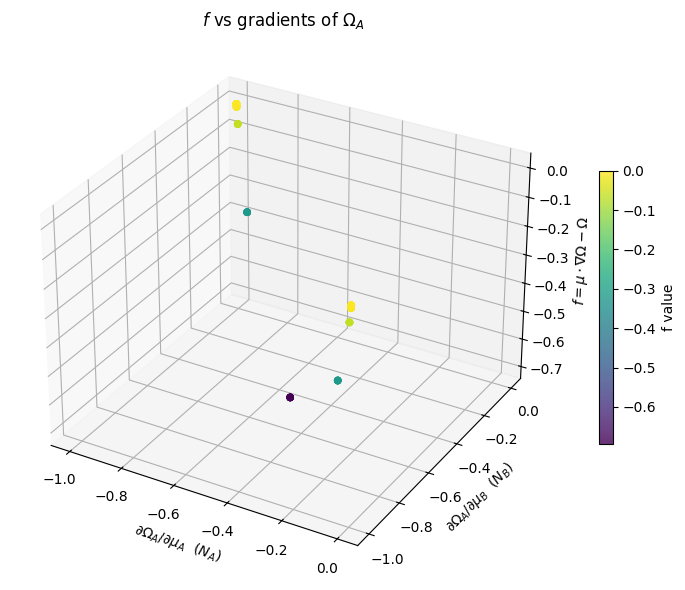

In [10]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# phase_a_grad shape: (10, 10, 2) — two derivatives per point
# f shape: (10, 10, 1)

grad_muA = phase_a_grad[..., 0].detach().numpy().flatten()  # d(phase_a)/d(mu_A)
grad_muB = phase_a_grad[..., 1].detach().numpy().flatten()  # d(phase_a)/d(mu_B)
f_vals   = f.detach().numpy().flatten()

fig = plt.figure(figsize=(9, 6))
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(grad_muA, grad_muB, f_vals,
                c=f_vals, cmap='viridis', s=20, alpha=0.8)

ax.set_xlabel(r'$\partial \Omega_A / \partial \mu_A$  ($N_A$)')
ax.set_ylabel(r'$\partial \Omega_A / \partial \mu_B$  ($N_B$)')
ax.set_zlabel(r'$f = \mu \cdot \nabla\Omega - \Omega$')
ax.set_title(r'$f$ vs gradients of $\Omega_A$')
fig.colorbar(sc, ax=ax, shrink=0.5, label='f value')

plt.tight_layout()
plt.show()

ValueError: x and y must have same first dimension, but have shapes (20,) and (100,)

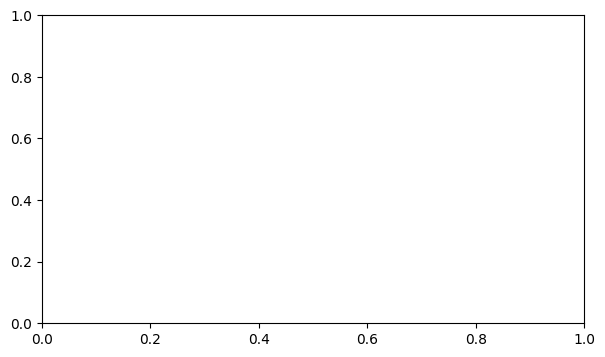

In [11]:
# Diagonal across the first two dimensions (i, i), then make it 1D
phase_a_diag = phase_a_output.flatten().detach().numpy()
phase_b_diag = phase_b_output.flatten().detach().numpy()
system_diag = system_output.flatten().detach().numpy()
muA_slice = input_tensor[:,0].squeeze(-1).flatten().detach().numpy()

plt.figure(figsize=(7, 4))
plt.plot(muA_slice, phase_a_diag, marker='o', linewidth=2, label='Phase A')
plt.plot(muA_slice, phase_b_diag, marker='s', linewidth=2, label='Phase B', color='orange')
plt.plot(muA_slice, system_diag, marker='^', linewidth=2, label='System', color='green')
plt.xlabel(r'$\mu_A$')
plt.ylabel('phase_a_output diagonal')
plt.title('Diagonal of phase_a_output vs mu_a')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
omega_a_vals = phase_a(inputs).detach().numpy().flatten()
mu_a_axis = inputs["mu_A"].detach().numpy().flatten()


helmholtz_a_vals, N_a_vals = phase_a.to_Helmholtz(inputs)
# Extract the particle number for the key 'mu_A'
N_a_axis = N_a_vals['mu_A'].detach().numpy().flatten()
helmholtz_a_vals = helmholtz_a_vals.detach().numpy().flatten()


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Grand Potential vs Chemical Potential
ax1.plot(mu_a_axis, omega_a_vals, 'b-', linewidth=2, marker='o', markersize=4)
ax1.set_xlabel(r'Chemical Potential $\mu_A$ (eV)')
ax1.set_ylabel(r'Grand Potential $\Omega_A$ (eV)')
ax1.set_title(r'$\Omega_A$ vs $\mu_A$')
ax1.grid(True, alpha=0.3)

# Plot 2: Helmholtz Free Energy vs Particle Number
if len(N_a_axis) > 0:
    ax2.plot(N_a_axis, helmholtz_a_vals, 'r-', linewidth=2, marker='s', markersize=4)
    ax2.set_xlabel(r'Expected Particle Number $\langle N_A \rangle$')
    ax2.set_ylabel(r'Helmholtz Free Energy $F_A$ (eV)')
    ax2.set_title(r'$F_A$ vs $N_A$')
    ax2.grid(True, alpha=0.3)



plt.tight_layout()
plt.show()

In [ ]:
omega_a_vals = phase_a(inputs).detach().numpy().flatten()
omega_b_vals = phase_b(inputs).detach().numpy().flatten()
mu_a_axis = inputs["mu_A"].detach().numpy().flatten()

plt.figure(figsize=(8, 5))
plt.plot(mu_a_axis, omega_a_vals, label=r'$\Omega_A$', linewidth=2)
plt.plot(mu_a_axis, omega_b_vals, label=r'$\Omega_B$', linewidth=2)
plt.xlabel(r'Chemical Potential $\mu_A$ (eV)')
plt.ylabel(r'Grand Potential $\Omega$ (eV)')
plt.title(r'$\Omega_A$ and $\Omega_B$ vs $\mu_A$')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
ideal_mixed = MixingNode([StackNode([phase_a, phase_b])], scale=1e-5)
omega = ideal_mixed

In [ ]:
import matplotlib.pyplot as plt
# 5. Visualization
Helmholtz_F, N_counts = omega.to_Helmholtz(inputs)
Omega = omega(inputs)

# Flatten() ensures everything is a 1D array for plotting
mu_axis = inputs['mu_A'].detach().numpy().flatten()
y_omega = Omega.detach().numpy().flatten()
y_helmholtz = Helmholtz_F.detach().numpy().flatten()
y_NA = N_counts['mu_A'].detach().numpy().flatten()

# Note: We do not simplify sorting here because F(N) needs N to be the x-axis, 
# and mu might not be monotonic with N in complex systems (though here it is).
sort_idx = mu_axis.argsort()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Grand Potential vs Chemical Potential (Natural Variables)
ax1.set_xlabel(r'Chemical Potential $\mu_A$')
ax1.set_ylabel(r'Grand Potential $\Omega$', color='tab:red')
ax1.plot(mu_axis[sort_idx], y_omega[sort_idx], 'r--', linewidth=2, label=r'$\Omega(\mu)$')
ax1.tick_params(axis='y', labelcolor='tab:red')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)
ax1.set_title(r'Grand Canonical Ensemble ($\mu \to \Omega$)')

# Plot 2: Helmholtz Free Energy vs Particle Number (Conjugate Variables)
# Ideally F is plotted against its natural variable N_A
# Sort by N_A for a clean line
sort_N = y_NA.argsort()

ax2.set_xlabel(r'Particle Fraction $N_A$')
ax2.set_ylabel(r'Helmholtz Free Energy $F$', color='tab:green')
ax2.plot(y_NA[sort_N], y_helmholtz[sort_N], 'g-', linewidth=3, label=r'$F(N)$', marker='o')
ax2.legend(loc='upper center')
ax2.grid(True, alpha=0.3)
ax2.set_title(r'Canonical Ensemble ($N \to F$)')

plt.tight_layout()
plt.show()